In [4]:
import pandas as pd
import numpy as np

# 1. Baca data mentah (ganti nama file sesuai dengan file aslimu)
df_raw = pd.read_csv('master_chat_wa.csv')

print(f"Total baris awal: {len(df_raw)}")

# 2. Hapus kolom yang tidak relevan untuk NLP
df = df_raw[['Formatted Name', 'Message Type', 'Message Body']].copy()

# 3. FILTER 1: Hanya ambil pesan dari Pelanggan (Buang pesan dari 'Anda')
df = df[df['Formatted Name'] != 'Anda']

# 4. FILTER 2: Hanya ambil tipe pesan teks (chat)
df = df[df['Message Type'] == 'chat']

# 5. FILTER 3: Buang pesan yang isinya cuma gambar/stiker/kosong
df = df[~df['Message Body'].astype(str).str.contains('【IMAGE】|【VIDEO】', case=False, na=False)]
df = df.dropna(subset=['Message Body'])

print(f"Total baris setelah dibersihkan (khusus teks pelanggan): {len(df)}")

# Tampilkan 5 data teratas untuk memastikan
display(df.head())

Total baris awal: 3171
Total baris setelah dibersihkan (khusus teks pelanggan): 1480


,Formatted Name,Message Type,Message Body
2,+62 811-5670-1235,chat,Oke bg
3,+62 811-5670-1235,chat,Bg berapa kemarin harganya ya
5,+62 811-5670-1235,chat,Okey bg
7,+62 811-5670-1235,chat,Tutup jam brp bg
9,+62 811-5670-1235,chat,Okey bg bntr lagi saya kesana


In [5]:
import pandas as pd

# Fungsi untuk melabeli teks berdasarkan kata kunci
def auto_label_intent(text):
    # Ubah menjadi string, lowercase, dan pastikan aman dari nilai kosong
    text = str(text).lower()
    
    # Memecah kalimat menjadi list kata untuk menghindari salah pencocokan 
    # (Misal: 'besok' tidak terbaca sebagai 'ok')
    words = text.split()
    
    # 1. Kata Kunci SETUJU
    # Pelanggan biasanya mengkonfirmasi servis atau menyetujui harga
    if any(word in text for word in ['lanjut', 'gas', 'setuju']) or \
       any(word in words for word in ['ok', 'oke', 'okee', 'okey', 'iya', 'sip', 'siap', 'baik']):
        return 'setuju'
    
    # 2. Kata Kunci BATAL
    # Pelanggan menolak servis, merasa kemahalan, atau menunda
    elif any(word in text for word in ['ga jadi', 'gak jadi', 'ndak jadi', 'ndak usah', 'gausah', 'gak usah']):
        return 'batal'
    
    # 3. Kata Kunci TANYA_STATUS
    # Pelanggan mem-follow up barang servisannya
    elif any(word in text for word in ['selesai', 'diambil', 'di ambek', 'udah betul', 'udh betul', 'gimana', 'gmn', 'kapan', 'progress']):
        return 'tanya_status'
    
    # 4. Sisanya masuk UMUM_TEKNIS (Tanya harga, jam buka, keluhan laptop rusak, nego, dll)
    else:
        return 'umum_teknis'

# Terapkan fungsi ke dalam kolom baru bernama 'Label'
df['Label'] = df['Message Body'].apply(auto_label_intent)

# Lihat distribusi jumlah per kelas (Penting untuk Screenshot Skripsi!)
print("\nDistribusi Kelas Niat:")
print(df['Label'].value_counts())

# Simpan hasilnya ke Excel agar bisa kamu verifikasi manual
df[['Message Body', 'Label']].to_excel('dataset_untuk_diverifikasi.xlsx', index=False)
print("\nFile 'dataset_untuk_diverifikasi.xlsx' berhasil dibuat!")


Distribusi Kelas Niat:
Label
umum_teknis     983
setuju          410
tanya_status     84
batal             3
Name: count, dtype: int64

File 'dataset_untuk_diverifikasi.xlsx' berhasil dibuat!


1. Membaca Dataset Final...
2. Memulai Preprocessing (Cleansing & Stemming Sastrawi)...
   (Proses ini mungkin memakan waktu beberapa menit tergantung jumlah data)


3. Melatih FastText (Feature Extraction)...
4. Membagi Data & Melatih SVM...
5. Evaluasi Model (Copy output ini untuk Bab 4 & 5)...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       batal       0.80      0.92      0.85        60
      setuju       1.00      0.63      0.78        60
tanya_status       0.86      0.95      0.90        60
 umum_teknis       0.87      0.97      0.91        60

    accuracy                           0.87       240
   macro avg       0.88      0.87      0.86       240
weighted avg       0.88      0.87      0.86       240

Akurasi Keseluruhan: 86.67%

6. Menggambar Confusion Matrix...


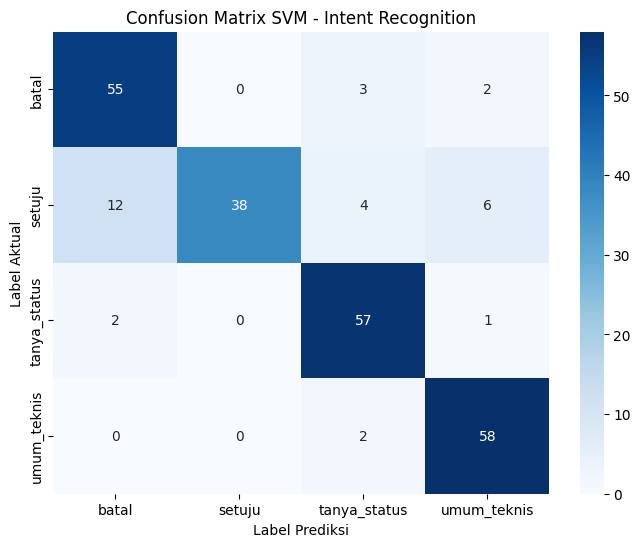

7. Menyimpan Otak SVM ke file .pkl...
SELESAI! Model siap digunakan di FastAPI.


In [6]:
import pandas as pd
import numpy as np
import re
import fasttext
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("1. Membaca Dataset Final...")
# Coba beberapa encoding untuk menghindari UnicodeDecodeError (mis. byte 0x92 dari cp1252)
df_final = pd.read_csv('dataset_final.csv')
df_final = df_final.dropna(subset=['Message Body', 'Label'])

print("2. Memulai Preprocessing (Cleansing & Stemming Sastrawi)...")
print("   (Proses ini mungkin memakan waktu beberapa menit tergantung jumlah data)")
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Hanya huruf
    text = re.sub(r'\s+', ' ', text).strip()
    return stemmer.stem(text)

df_final['Clean_Text'] = df_final['Message Body'].apply(preprocess_text)

print("3. Melatih FastText (Feature Extraction)...")
# Simpan sementara untuk FastText
with open('corpus_fasttext_final.txt', 'w', encoding='utf-8') as f:
    for text in df_final['Clean_Text']:
        if str(text).strip(): # Hindari baris kosong
            f.write(str(text) + '\n')

# Train model FastText
ft_model = fasttext.train_unsupervised('corpus_fasttext_final.txt', model='skipgram', dim=100, epoch=50)
ft_model.save_model("fasttext_model.bin")

# Fungsi konversi teks ke vektor
def get_sentence_vector(text):
    return ft_model.get_sentence_vector(str(text))

X = np.array(df_final['Clean_Text'].apply(get_sentence_vector).tolist())
y = df_final['Label'].values

print("4. Membagi Data & Melatih SVM...")
# Split 80% Train, 20% Test (Sesuai bab 3 skripsi)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# INI KUNCINYA: class_weight='balanced' agar SVM tidak bias ke kelas yang datanya banyak
svm_model = SVC(kernel='linear', probability=True, C=1.0, class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)

print("5. Evaluasi Model (Copy output ini untuk Bab 4 & 5)...\n")
y_pred = svm_model.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("6. Menggambar Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('Confusion Matrix SVM - Intent Recognition')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.show()

print("7. Menyimpan Otak SVM ke file .pkl...")
joblib.dump(svm_model, 'svm_model.pkl')
print("SELESAI! Model siap digunakan di FastAPI.")